In [1]:
import pandas as pd
import sys
import numpy as np

In [2]:
# make a list of file in the directory

import os

folder_of_interest_list = [
    'results_shipsnet_v02_00_SEU',
    'results_shipsnet_v02_01_SEU',
    'results_shipsnet_v02_02_SEU',
    'results_shipsnet_v02_03_SEU',
    ]

df_master = pd.read_csv(r'results_shipsnet_new_uniform\results_shipsnet_v02_00_SEU\_20250806_013752.csv')
# delete all rows leaving the columns only
# add a column called folder_name
df_master['folder_name'] = ""
df_master = df_master.drop(df_master.index)

for foil in folder_of_interest_list:

#folder_of_interest = 'results_shipsnet_01_SEU'
#folder_of_interest = 'results_GP_shipsnet_newslate_guide_SEU'

#df_master = pd.read_csv(r'results_4_variants\results_GP_shipsnet_newslate_guide_SEU\_20250718_234102.csv')
# add a column called timestamp, which is the filename without the extension
#df_master['timestamp'] = ""

    search_dir = os.path.join('results_shipsnet_new_uniform',
                            foil,
    )

    for file in os.listdir(search_dir):
        if file.endswith('.csv'):
            file_path = os.path.join(search_dir, file)
            print(f"Processing file: {file_path}")
            df = pd.read_csv(file_path)
            df['folder_name'] = foil
            # remove if accuracy_after_seu is nan
            df = df[df['accuracy_after_seu'].notna()]
            print(f"Number of rows after removing NaN in 'accuracy_after_seu': {len(df)}")
            #remove duplicate rows based on the first 10 columns
            print(f"Number of rows before dropping duplicates: {len(df)}")
            df = df.drop_duplicates(subset=df.columns[:10])
            print(f"Number of rows after dropping duplicates: {len(df)}")
            # append the data to the master dataframe
            df_master = pd.concat([df_master, df], ignore_index=True)
    #

# filter accuracy_change to only non nan values
#abs_acc_change_mean = df_master[df_master['accuracy_change'].notna()]['accuracy_change'].abs().mean()
#abs_acc_change_mean\
df_master['abs_acc_diff'] = df_master['accuracy_change'].abs()
df_master['log_mean_abs_difference'] = df_master['mean_abs_difference'].apply(lambda x: np.log10(x) if x > 0 else np.nan)

Processing file: results_shipsnet_new_uniform\results_shipsnet_v02_00_SEU\_20250806_013752.csv
Number of rows after removing NaN in 'accuracy_after_seu': 156
Number of rows before dropping duplicates: 156
Number of rows after dropping duplicates: 156
Processing file: results_shipsnet_new_uniform\results_shipsnet_v02_00_SEU\_20250806_014138.csv
Number of rows after removing NaN in 'accuracy_after_seu': 156
Number of rows before dropping duplicates: 156
Number of rows after dropping duplicates: 156
Processing file: results_shipsnet_new_uniform\results_shipsnet_v02_00_SEU\_20250806_014145.csv
Number of rows after removing NaN in 'accuracy_after_seu': 156
Number of rows before dropping duplicates: 156
Number of rows after dropping duplicates: 156
Processing file: results_shipsnet_new_uniform\results_shipsnet_v02_00_SEU\_20250806_022604.csv
Number of rows after removing NaN in 'accuracy_after_seu': 156
Number of rows before dropping duplicates: 156
Number of rows after dropping duplicates: 

In [3]:
df_master

,activation_fn,prior,best_accuracy,prior_mu,prior_b,param_type,location_index,location_layer,location_module,bit_index,initial_accuracy,accuracy_after_seu,accuracy_change,softmax_difference,mean_abs_difference,remarks,original_bit_condition,folder_name,abs_acc_diff,log_mean_abs_difference
0,relu,uniform,0.868437,0.0,1.0,lows,0,conv1,weight,0,0.91375,0.91875,0.00500,0.296412,5.618616e-01,NaN,1,results_shipsnet_v02_00_SEU,0.00500,-0.250371
1,relu,uniform,0.868437,0.0,1.0,lows,0,conv1,weight,1,0.91375,0.75125,-0.16250,0.946326,9.559580e+37,AutoUniform width adjusted;,0,results_shipsnet_v02_00_SEU,0.16250,37.980439
2,relu,uniform,0.868437,0.0,1.0,widths,0,conv1,weight,1,0.91375,0.75000,-0.16375,0.970758,2.162142e+38,NaN,0,results_shipsnet_v02_00_SEU,0.16375,38.334884
3,relu,uniform,0.868437,0.0,1.0,lows,0,conv1,weight,3,0.91375,0.91250,-0.00125,0.289381,2.809308e-01,NaN,1,results_shipsnet_v02_00_SEU,0.00125,-0.551401
4,relu,uniform,0.868437,0.0,1.0,widths,0,conv1,weight,3,0.91375,0.91500,0.00125,0.292479,6.353964e-01,AutoUniform width adjusted;,1,results_shipsnet_v02_00_SEU,0.00125,-0.196955
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13255,actRWG,gaussian,0.694688,0.0,1.0,scales,-1,fc1,bias,10,0.75625,0.75250,-0.00375,0.271547,1.250000e-01,NaN,1,results_shipsnet_v02_03_SEU,0.00375,-0.903090
13256,actRWG,gaussian,0.694688,0.0,1.0,locs,-1,fc1,bias,15,0.75625,0.75625,0.00000,0.276037,6.103516e-05,NaN,1,results_shipsnet_v02_03_SEU,0.00000,-4.214420
13257,actRWG,gaussian,0.694688,0.0,1.0,scales,-1,fc1,bias,15,0.75625,0.75625,0.00000,0.275937,3.906250e-03,NaN,0,results_shipsnet_v02_03_SEU,0.00000,-2.408240
13258,actRWG,gaussian,0.694688,0.0,1.0,locs,-1,fc1,bias,21,0.75625,0.75750,0.00125,0.273938,9.536743e-07,NaN,0,results_shipsnet_v02_03_SEU,0.00125,-6.020600


In [4]:
df_master["bit_index"].unique()

array([ 0,  1,  3,  6, 10, 15, 21])

In [5]:
df_master[(df_master['bit_index'] == 1) & (df_master['prior'] == 'uniform')]

,activation_fn,prior,best_accuracy,prior_mu,prior_b,param_type,location_index,location_layer,location_module,bit_index,initial_accuracy,accuracy_after_seu,accuracy_change,softmax_difference,mean_abs_difference,remarks,original_bit_condition,folder_name,abs_acc_diff,log_mean_abs_difference
1,relu,uniform,0.868437,0.0,1.0,lows,0,conv1,weight,1,0.91375,0.75125,-0.16250,0.946326,9.559580e+37,AutoUniform width adjusted;,0,results_shipsnet_v02_00_SEU,0.16250,37.980439
2,relu,uniform,0.868437,0.0,1.0,widths,0,conv1,weight,1,0.91375,0.75000,-0.16375,0.970758,2.162142e+38,NaN,0,results_shipsnet_v02_00_SEU,0.16375,38.334884
14,relu,uniform,0.868437,0.0,1.0,lows,0,conv1,bias,1,0.91375,0.91375,0.00000,0.293230,1.742523e+38,AutoUniform width adjusted;,0,results_shipsnet_v02_00_SEU,0.00000,38.241179
15,relu,uniform,0.868437,0.0,1.0,widths,0,conv1,bias,1,0.91375,0.75000,-0.16375,1.000000,1.665448e+38,NaN,0,results_shipsnet_v02_00_SEU,0.16375,38.221531
27,relu,uniform,0.868437,0.0,1.0,lows,0,conv2,weight,1,0.91375,0.72625,-0.18750,0.956189,1.460014e+38,AutoUniform width adjusted;,0,results_shipsnet_v02_00_SEU,0.18750,38.164357
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12287,actRWG,uniform,0.673750,0.0,1.0,widths,-1,conv2,bias,1,0.74125,0.74500,0.00375,0.210135,2.728738e+38,NaN,0,results_shipsnet_v02_03_SEU,0.00375,38.435962
12299,actRWG,uniform,0.673750,0.0,1.0,lows,-1,fc1,weight,1,0.74125,0.74625,0.00500,0.198738,7.601494e+37,AutoUniform width adjusted;,0,results_shipsnet_v02_03_SEU,0.00500,37.880899
12300,actRWG,uniform,0.673750,0.0,1.0,widths,-1,fc1,weight,1,0.74125,0.29500,-0.44625,0.484886,3.402823e+38,SEU went to NaN or Inf clipping to finite range;,0,results_shipsnet_v02_03_SEU,0.44625,38.531839
12312,actRWG,uniform,0.673750,0.0,1.0,lows,-1,fc1,bias,1,0.74125,0.75000,0.00875,0.200032,1.648301e+38,AutoUniform width adjusted;,0,results_shipsnet_v02_03_SEU,0.00875,38.217037


In [6]:
df_summary = df_master.groupby(['activation_fn',
                   'prior',
                   'param_type',
                   'location_index',
                   'location_layer',
                   'location_module',
                   'folder_name'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
df_summary

,activation_fn,prior,param_type,location_index,location_layer,location_module,folder_name,abs_acc_diff,softmax_difference
0,actRWG,gaussian,locs,-1,conv1,bias,results_shipsnet_v02_00_SEU,0.005714,0.274276
1,actRWG,gaussian,locs,-1,conv1,bias,results_shipsnet_v02_01_SEU,0.003929,0.277222
2,actRWG,gaussian,locs,-1,conv1,bias,results_shipsnet_v02_02_SEU,0.003036,0.271854
3,actRWG,gaussian,locs,-1,conv1,bias,results_shipsnet_v02_03_SEU,0.001786,0.274763
4,actRWG,gaussian,locs,-1,conv1,weight,results_shipsnet_v02_00_SEU,0.003393,0.272917
...,...,...,...,...,...,...,...,...,...
2011,tanh,uniform,widths,0,fc1,bias,results_shipsnet_v02_03_SEU,0.031458,0.416238
2012,tanh,uniform,widths,0,fc1,weight,results_shipsnet_v02_00_SEU,0.029792,0.400714
2013,tanh,uniform,widths,0,fc1,weight,results_shipsnet_v02_01_SEU,0.033125,0.409495
2014,tanh,uniform,widths,0,fc1,weight,results_shipsnet_v02_02_SEU,0.027708,0.404244


In [7]:
df_master.sort_values(by='abs_acc_diff', ascending=False)

,activation_fn,prior,best_accuracy,prior_mu,prior_b,param_type,location_index,location_layer,location_module,bit_index,initial_accuracy,accuracy_after_seu,accuracy_change,softmax_difference,mean_abs_difference,remarks,original_bit_condition,folder_name,abs_acc_diff,log_mean_abs_difference
7866,sin,uniform,0.890312,0.0,1.0,lows,0,fc1,bias,1,0.92250,0.25000,-0.67250,0.610711,1.109772e+37,AutoUniform width adjusted;,0,results_shipsnet_v02_02_SEU,0.67250,37.045234
3719,relu,gaussian,0.866250,0.0,1.0,locs,-1,fc1,weight,1,0.92250,0.25000,-0.67250,0.623565,1.880074e+35,NaN,0,results_shipsnet_v02_01_SEU,0.67250,35.274175
7945,sin,uniform,0.890312,0.0,1.0,widths,-1,fc1,bias,1,0.92250,0.25000,-0.67250,1.000000,3.402823e+38,SEU went to NaN or Inf clipping to finite range;,0,results_shipsnet_v02_02_SEU,0.67250,38.531839
3641,relu,gaussian,0.866250,0.0,1.0,locs,0,fc1,weight,1,0.92250,0.25000,-0.67250,0.623565,8.096156e+36,NaN,0,results_shipsnet_v02_01_SEU,0.67250,36.908279
4500,sin,uniform,0.875625,0.0,1.0,widths,-1,fc1,weight,1,0.92125,0.25000,-0.67125,0.998991,3.402823e+38,SEU went to NaN or Inf clipping to finite range;,0,results_shipsnet_v02_01_SEU,0.67125,38.531839
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13138,actRWG,gaussian,0.694688,0.0,1.0,scales,0,conv2,weight,10,0.75625,0.75625,0.00000,0.275977,1.250000e-01,NaN,0,results_shipsnet_v02_03_SEU,0.00000,-0.903090
13139,actRWG,gaussian,0.694688,0.0,1.0,locs,0,conv2,weight,15,0.75625,0.75625,0.00000,0.272352,1.525879e-05,NaN,1,results_shipsnet_v02_03_SEU,0.00000,-4.816480
13256,actRWG,gaussian,0.694688,0.0,1.0,locs,-1,fc1,bias,15,0.75625,0.75625,0.00000,0.276037,6.103516e-05,NaN,1,results_shipsnet_v02_03_SEU,0.00000,-4.214420
8082,sigmoid,laplace,0.686562,0.0,1.0,locs,-1,conv2,bias,15,0.75000,0.75000,0.00000,0.268541,9.765625e-04,NaN,1,results_shipsnet_v02_02_SEU,0.00000,-3.010300


In [ ]:
#df_master[df_master['bit_index']==1].to_csv("index_1_check.csv", index=False)

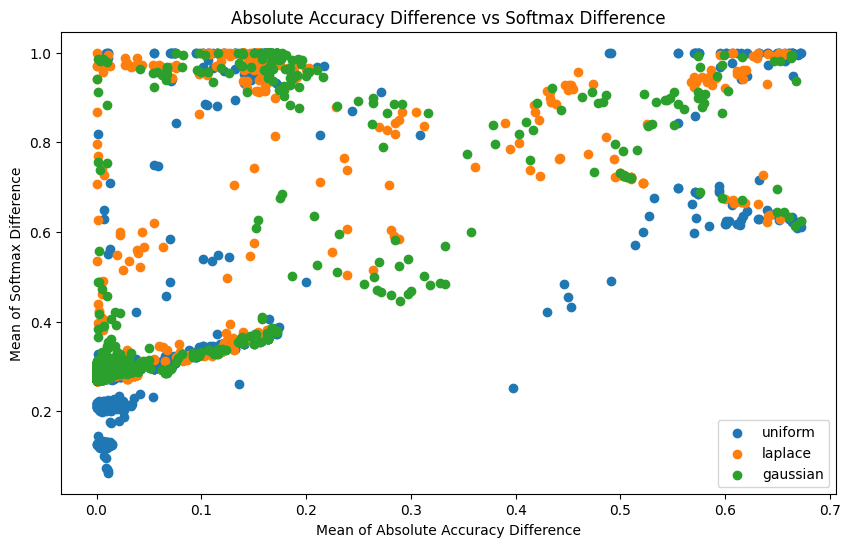

In [8]:
# make a scatter plot of abs_acc_diff vs softmax_difference
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
for prior in df_master['prior'].unique():
    subset = df_master[df_master['prior'] == prior]
    plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=prior)
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference')
plt.legend()
plt.show()

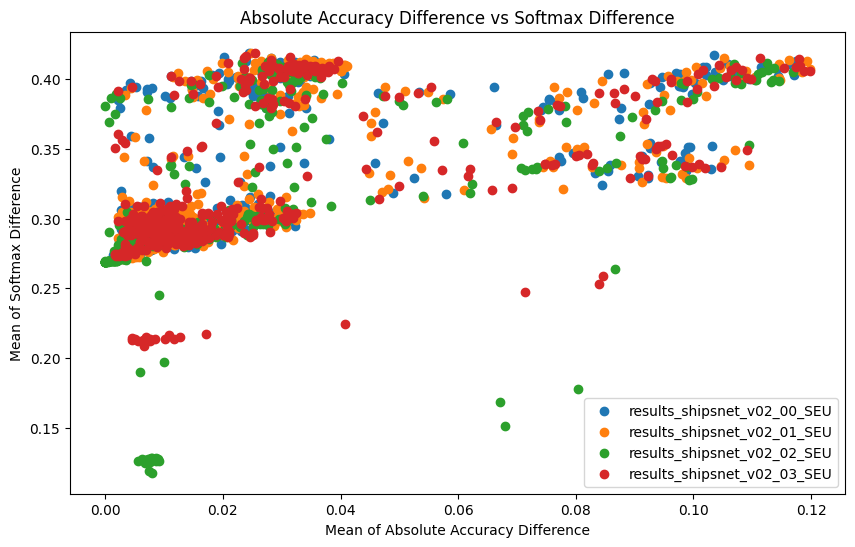

In [9]:
# make a scatter plot of abs_acc_diff vs softmax_difference
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
for folder in df_summary['folder_name'].unique():
    subset = df_summary[df_summary['folder_name'] == folder]
    plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=folder)
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference')
plt.legend()
plt.show()

In [10]:
df_summary_2 = df_master.groupby(['location_layer',
                                  'location_module'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
df_summary_2

,location_layer,location_module,abs_acc_diff,softmax_difference
0,conv1,bias,0.009562,0.294681
1,conv1,weight,0.013196,0.303386
2,conv2,bias,0.008994,0.301326
3,conv2,weight,0.013787,0.321217
4,fc1,bias,0.045893,0.351939
5,fc1,weight,0.055615,0.346590


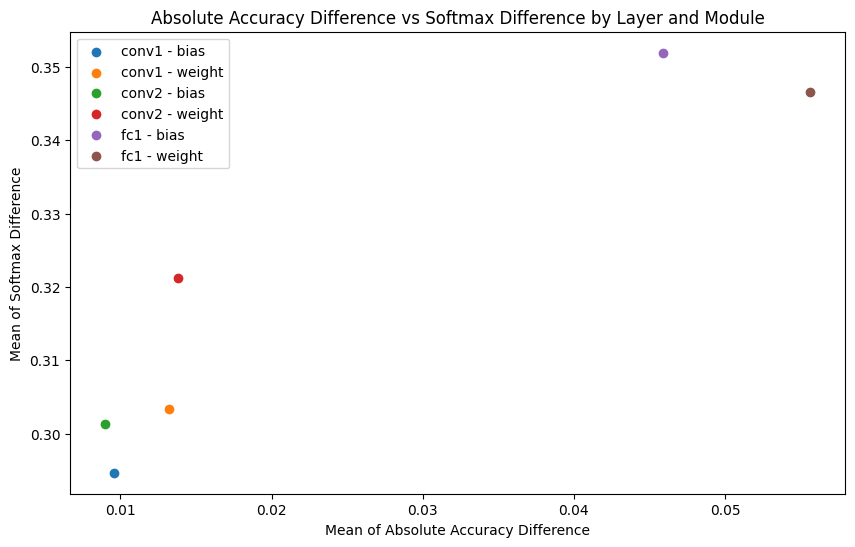

In [11]:
# make a scatter plot of abs_acc_diff vs softmax_difference
# create different shape by location_layer and location_module
plt.figure(figsize=(10, 6))
for layer in df_summary_2['location_layer'].unique():
    for module in df_summary_2['location_module'].unique():
        subset = df_summary_2[(df_summary_2['location_layer'] == layer) & (df_summary_2['location_module'] == module)]
        plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=f'{layer} - {module}')
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference by Layer and Module')
plt.legend()

In [12]:
df_summary_3 = df_master.groupby(['activation_fn'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
df_summary_3

,activation_fn,abs_acc_diff,softmax_difference
0,actRWG,0.016496,0.287959
1,actWG,0.021318,0.304823
2,relu,0.038527,0.368834
3,relu6,0.024762,0.320665
4,sigmoid,0.019129,0.306760
5,sin,0.028950,0.323144
6,tanh,0.021205,0.322728


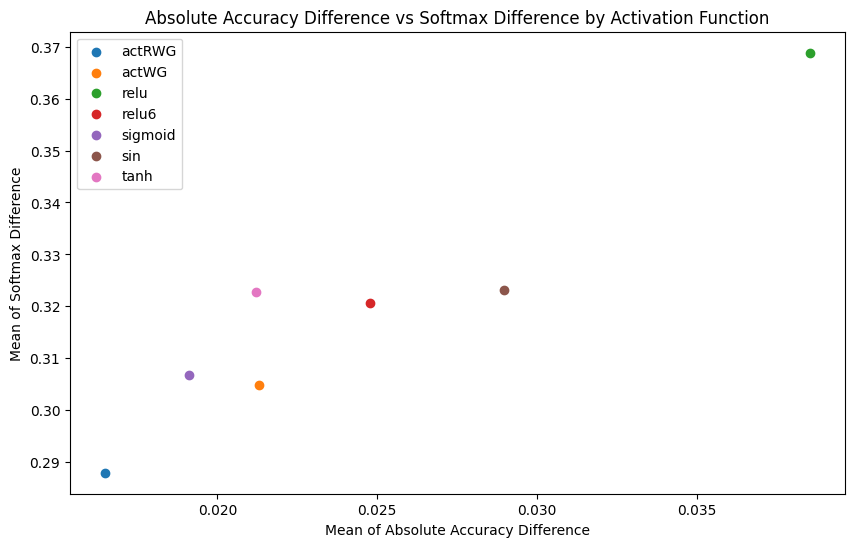

In [13]:
# make a scatter plot of abs_acc_diff vs softmax_difference
plt.figure(figsize=(10, 6))
for activation in df_summary_3['activation_fn'].unique():
    subset = df_summary_3[df_summary_3['activation_fn'] == activation]
    plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=activation)
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference by Activation Function')
plt.legend()

In [14]:
df_summary_4 = df_master.groupby(['prior'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
df_summary_4

,prior,abs_acc_diff,softmax_difference
0,gaussian,0.023051,0.320512
1,laplace,0.024022,0.326524
2,uniform,0.026467,0.312295


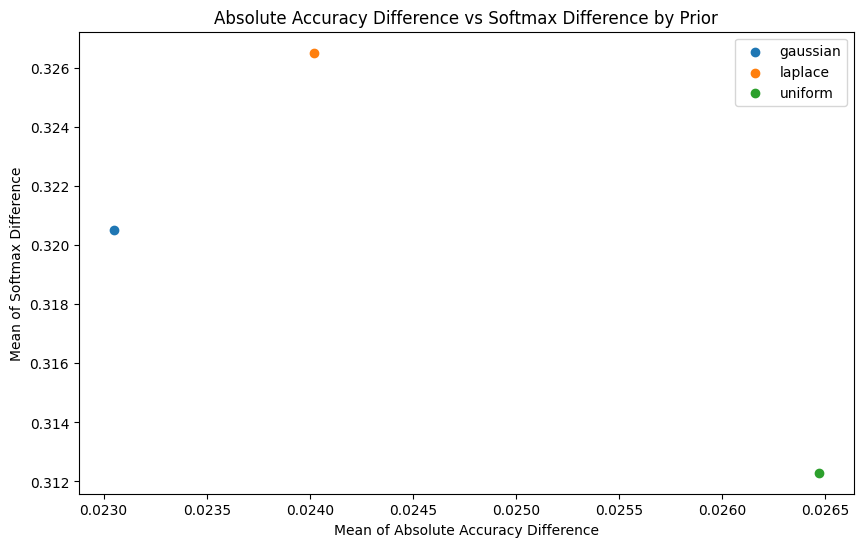

In [15]:
# make a scatter plot of abs_acc_diff vs softmax_difference
plt.figure(figsize=(10, 6))
for prior in df_summary_4['prior'].unique():
    subset = df_summary_4[df_summary_4['prior'] == prior]
    plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=prior)
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference by Prior')
plt.legend()
plt.show()

In [16]:
df_summary_5 = df_master.groupby(['prior','param_type'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
df_summary_5

,prior,param_type,abs_acc_diff,softmax_difference
0,gaussian,locs,0.017708,0.302908
1,gaussian,scales,0.029284,0.341051
2,laplace,locs,0.019691,0.308039
3,laplace,scales,0.029076,0.348091
4,uniform,lows,0.023150,0.296358
5,uniform,widths,0.030337,0.330889


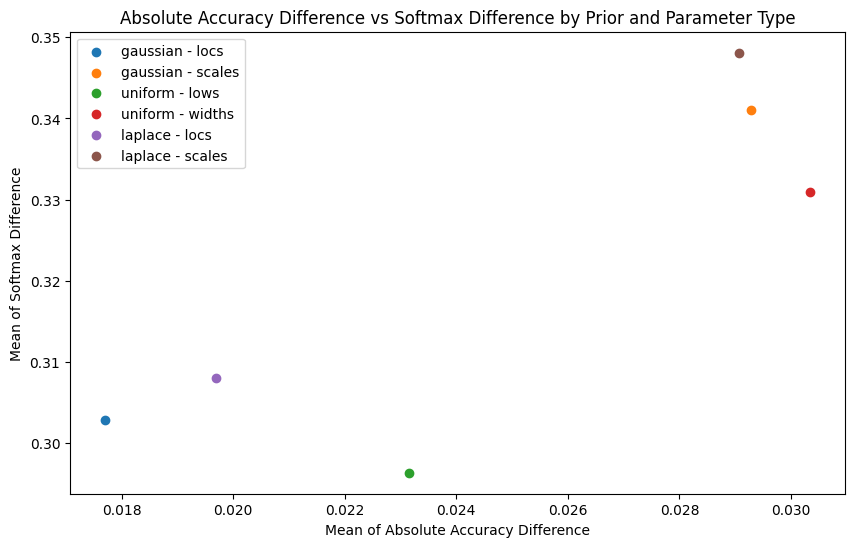

In [17]:
# make a scatter plot of abs_acc_diff vs softmax_difference
plt.figure(figsize=(10, 6))

# make a custom cumbination of prior and param_type
param_dict = {
    'gaussian': ['locs','scales'],
    'uniform': ['lows','widths'],
    'laplace': ['locs','scales'],}

# giva a very contrast different color other that seaborn-darkgrid
import matplotlib.pyplot as plt
#plt.style.use('seaborn-darkgrid')

for prior in param_dict.keys():
    for param_type in param_dict[prior]:
        subset = df_summary_5[(df_summary_5['prior'] == prior) & (df_summary_5['param_type'] == param_type)]
        plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=f'{prior} - {param_type}')


plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference by Prior and Parameter Type')
plt.legend()
plt.show()

In [18]:
df_summary_6 = df_master.groupby(['folder_name'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
df_summary_6

,folder_name,abs_acc_diff,softmax_difference
0,results_shipsnet_v02_00_SEU,0.024265,0.324338
1,results_shipsnet_v02_01_SEU,0.025867,0.325652
2,results_shipsnet_v02_02_SEU,0.022094,0.309720
3,results_shipsnet_v02_03_SEU,0.025739,0.319441


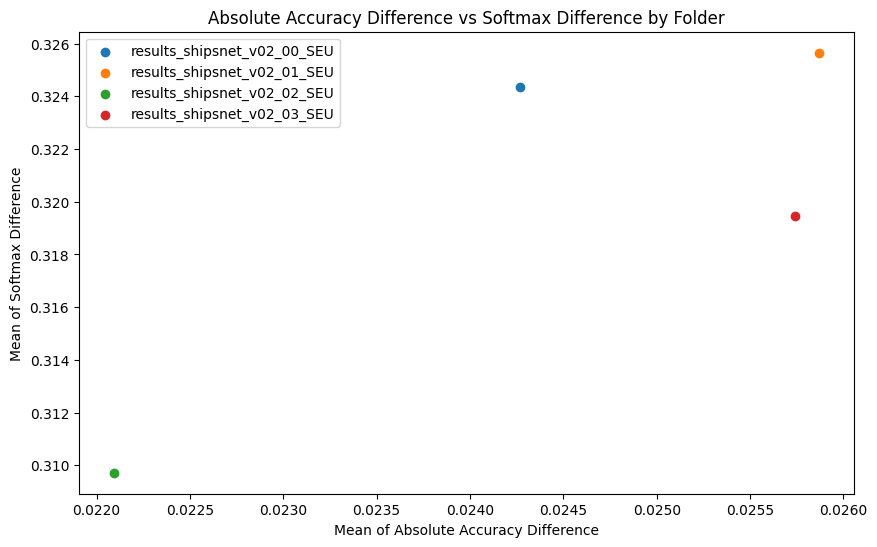

In [19]:
# make a scatter plot of abs_acc_diff vs softmax_difference from df_summary_6
plt.figure(figsize=(10, 6))
for folder in df_summary_6['folder_name'].unique():
    subset = df_summary_6[df_summary_6['folder_name'] == folder]
    plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=folder)
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference by Folder')
plt.legend()
plt.show()


In [20]:
df_summary_7 = df_master.groupby(['location_index','location_layer', 'location_module'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
df_summary_7

,location_index,location_layer,location_module,abs_acc_diff,softmax_difference
0,-1,conv1,bias,0.009566,0.294652
1,-1,conv1,weight,0.013170,0.303211
2,-1,conv2,bias,0.009152,0.301954
3,-1,conv2,weight,0.013071,0.311091
4,-1,fc1,bias,0.058340,0.338760
5,-1,fc1,weight,0.063186,0.341930
6,0,conv1,bias,0.009558,0.294711
7,0,conv1,weight,0.013222,0.303561
8,0,conv2,bias,0.008836,0.300699
9,0,conv2,weight,0.014503,0.331343


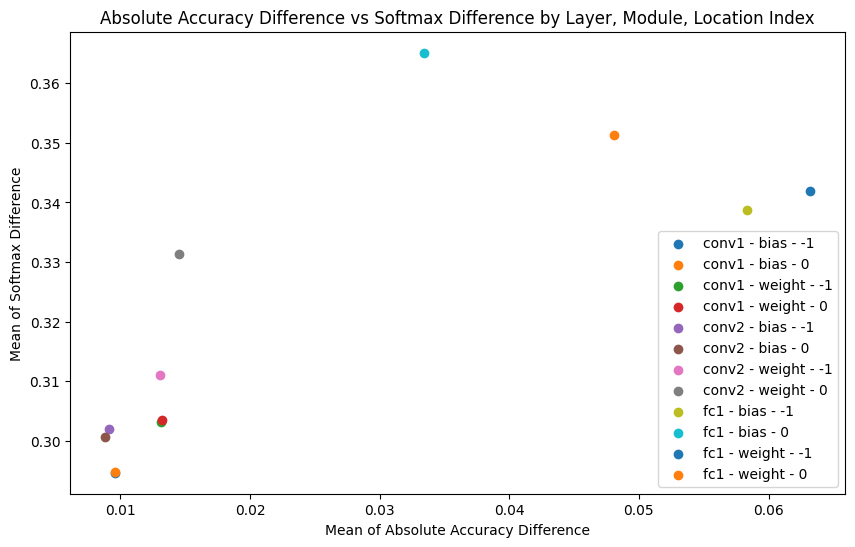

In [21]:
plt.figure(figsize=(10, 6))
for layer in df_summary_7['location_layer'].unique():
    for module in df_summary_7['location_module'].unique():
        for location_index in df_summary_7['location_index'].unique():
            subset = df_summary_7[(df_summary_7['location_layer'] == layer) & (df_summary_7['location_module'] == module) & (df_summary_7['location_index'] == location_index)]
            plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'],label=f'{layer} - {module} - {location_index}')
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference by Layer, Module, Location Index')
plt.legend()
plt.show()

In [ ]:
df_summary_8 = df_master.groupby(['original_bit_condition'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
df_summary_8

# robust machine learning systems pdf
# the bit-flips from 1 to 0 have a more drastic effect on the system’s classification accuracy than bit-flips from 0 to 1 [132]
# my result shows that bit-flips from 0 to 1 have a more drastic effect

,original_bit_condition,abs_acc_diff,softmax_difference
0,0,0.045702,0.361429
1,1,0.006981,0.285478


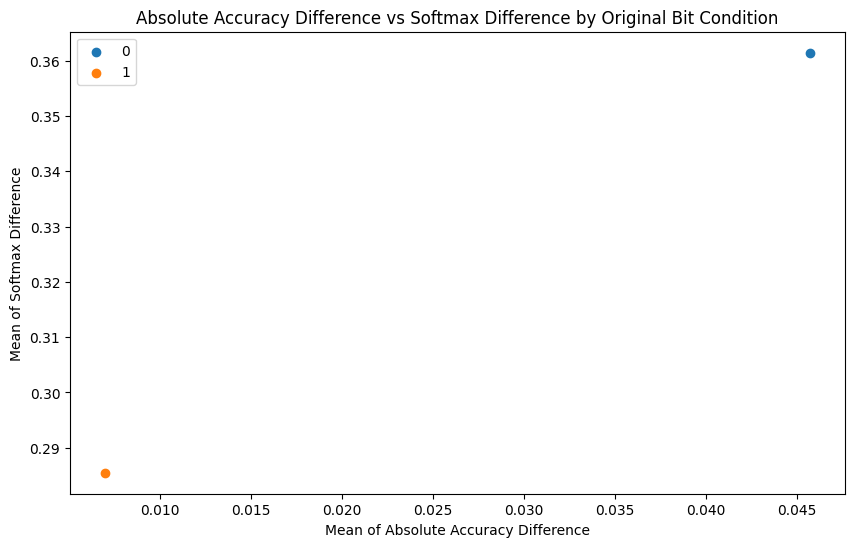

In [25]:
plt.figure(figsize=(10, 6))
for orbitloc in df_summary_8['original_bit_condition'].unique():
    subset = df_summary_8[(df_summary_8['original_bit_condition']==orbitloc)]
    plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'],label=f'{orbitloc}')
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference by Original Bit Condition')
plt.legend()
plt.show()

In [ ]:
# filter df to only show those with prior_b = 1
prior_b_filter = 1.0
activation_fn_filter = 'actWG'
prior_filter = 'gaussian'
param_type_filter = 'locs'


df_target = df_master[(df_master['prior_b'] == prior_b_filter) & 
                      (df_master['activation_fn'] == activation_fn_filter) &
                      #(df_master['bit_index'] == 1) &
                      (df_master['prior'] == prior_filter) &
                      (df_master['param_type'] == param_type_filter)].reset_index(drop=True)

#mean_acc_diff = df_target['abs_acc_diff'].mean()

#df_target = df_target[df_target['activation_fn'] == 'relu'].reset_index(drop=True)
#df_target = df_target[df_target['bit_index'] == 1].reset_index(drop=True)
#df_target = df_target[df_target['prior'] == 'gaussian'].reset_index(drop=True)
df_target

In [ ]:
# plot the result
# x axis is the absoulte value of the difference of accuracy
# y axis is the log of the mean_abs_difference
import matplotlib.pyplot as plt
import numpy as np

df_target['abs_acc_diff'] = df_target['accuracy_change'].abs()
df_target['log_mean_abs_difference'] = df_target['mean_abs_difference'].apply(lambda x: np.log10(x) if x > 0 else pd.np.nan)

abs_acc_change_mean = df_target[df_target['accuracy_change'].notna()]['accuracy_change'].abs().mean()

#color by the bit_index
df_target['bit_index'] = df_target['bit_index'].astype(str)

plt.figure(figsize=(10, 6))
#plt.scatter(df_target['abs_acc_diff'], df_target['log_mean_abs_difference'], alpha=0.5)
# add folder_of_interest, prior_b, activation_fn, prior, param_type to the title
#plt.title(f'Absolute Mean in Accuracy vs Log Mean Absolute Difference\nShipsNet SEU Analysis: {folder_of_interest} | Prior b: {prior_b_filter} | \nActivation Function: {activation_fn_filter} | Prior: {prior_filter} | Param Type: {param_type_filter}\n Mean Accuracy Difference: {abs_acc_change_mean:.4f}')
#plt.title('Absolute Mean in Accuracy vs Log Mean Absolute Difference')
plt.xlabel('Absolute Difference of Accuracy')
plt.ylabel('Log Mean Absolute Difference')
#plt.yscale('log')

# create a dictionary to map bit_index to colors
colors = {'0': 'blue', 
          '1': 'orange', 
          '3': 'green', 
          '6': 'red', 
          '10': 'purple', 
          '15': 'brown', 
          '21': 'pink', 
          '30': 'gray'}

plt.scatter(df_target['abs_acc_diff'], 
            df_target['log_mean_abs_difference'],
            c=df_target['bit_index'].map(colors),
            alpha=0.5, label=df_target['bit_index'])

#show legend
#plt.colorbar(label='Bit Index')
plt.grid(True)
plt.show()

In [ ]:
stopdeh

In [ ]:
df_target

In [ ]:
df_target = df_master[(df_master['prior_b'] == 1.0) & 
                      (df_master['activation_fn'] == 'relu') &
                      #(df_master['bit_index'] == 1) &
                      (df_master['prior'] == 'gaussian') &
                      (df_master['param_type'] == 'scales')].reset_index(drop=True)

#df_target = df_target[df_target['activation_fn'] == 'relu'].reset_index(drop=True)
#df_target = df_target[df_target['bit_index'] == 1].reset_index(drop=True)
#df_target = df_target[df_target['prior'] == 'gaussian'].reset_index(drop=True)
df_target

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

df_target['abs_acc_diff'] = df_target['accuracy_change'].abs()
df_target['log_mean_abs_difference'] = df_target['mean_abs_difference'].apply(lambda x: np.log10(x) if x > 0 else pd.np.nan)

#color by the bit_index
df_target['bit_index'] = df_target['bit_index'].astype(str)

plt.figure(figsize=(10, 6))
#plt.scatter(df_target['abs_acc_diff'], df_target['log_mean_abs_difference'], alpha=0.5)
plt.title('Softmax Difference vs Log Mean Absolute Difference')
plt.xlabel('Absolute Difference of Accuracy')
plt.ylabel('Log Mean Absolute Difference')
#plt.yscale('log')

# create a dictionary to map bit_index to colors
colors = {'0': 'blue', 
          '1': 'orange', 
          '3': 'green', 
          '6': 'red', 
          '10': 'purple', 
          '15': 'brown', 
          '21': 'pink', 
          '30': 'gray'}

plt.scatter(df_target['abs_acc_diff'], 
            df_target['log_mean_abs_difference'],
            c=df_target['bit_index'].map(colors),
            alpha=0.5, label=df_target['bit_index'])

#show legend
#plt.colorbar(label='Bit Index')
plt.grid(True)
plt.show()

In [ ]:
def plot_seu_result():
    """
    input : what variables to show, what parameters to filter
    output : show graph
    """

    # plot the graph

    pass